# Trabalho C3 - Análise de Dados e Machine Learning

**Tema:** Preços de casas nos Estados Unidos  
**Dataset:** House Prices - Advanced Regression Techniques

Neste notebook eu vou seguir as etapas pedidas no trabalho C3: análise exploratória, feature engineering, regressão, classificação, clusterização, redução de dimensionalidade, associação, outliers e visualizações.

A ideia foi manter o desenvolvimento de forma simples, usando principalmente o que foi visto em aula: `pandas`, gráficos com `matplotlib`, regressão linear, KNN, K-Means, PCA, Apriori e Local Outlier Factor.


## 1. Importação das bibliotecas

Nesta primeira parte, importei as bibliotecas que serão usadas no notebook. Tentei manter somente bibliotecas comuns das aulas e do conteúdo disponibilizado pelo professor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score

# Bibliotecas para análise de associação
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except:
    !pip install mlxtend -q
    from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-sql-connector 4.2.4 requires pandas<2.4.0,>=2.2.3; python_version >= "3.13", but you have pandas 3.0.3 which is incompatible.


## 2. Carregamento do dataset

Aqui eu carreguei o arquivo `train.csv`, que contém as casas com o preço de venda (`SalePrice`). Esse é o arquivo principal para treinamento e análise.

In [2]:
df_original = pd.read_csv('train.csv')

# Criei uma cópia para trabalhar sem alterar o dataset original
df = df_original.copy()

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Informações iniciais dos dados

Nesta parte, olhei o tamanho do dataset, os tipos das colunas e uma descrição inicial das variáveis numéricas. Isso ajuda a entender melhor o conjunto antes de aplicar qualquer modelo.

In [3]:
print('Quantidade de linhas e colunas:', df.shape)
print('\nPrimeiras informações das colunas:')
df.info()

Quantidade de linhas e colunas: (1460, 81)

Primeiras informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     14

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 4. Separação entre variáveis numéricas e categóricas

Como foi visto em aula, muitos algoritmos de Machine Learning funcionam melhor com dados numéricos. Por isso, separei as colunas numéricas e categóricas para entender melhor o dataset.

In [5]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

print('Quantidade de variáveis numéricas:', len(colunas_numericas))
print('Quantidade de variáveis categóricas:', len(colunas_categoricas))

print('\nExemplos de colunas numéricas:')
print(list(colunas_numericas[:10]))

print('\nExemplos de colunas categóricas:')
print(list(colunas_categoricas[:10]))

Quantidade de variáveis numéricas: 38
Quantidade de variáveis categóricas: 43

Exemplos de colunas numéricas:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']

Exemplos de colunas categóricas:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


## 5. Valores ausentes

Aqui verifiquei quais colunas possuem valores faltantes. Essa etapa é importante porque valores ausentes podem atrapalhar o treinamento dos modelos.

In [6]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
faltantes

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

### Interpretação dos valores ausentes

Algumas colunas têm muitos valores ausentes, principalmente colunas relacionadas a características que nem toda casa possui, como piscina, cerca, garagem ou beco. Nesses casos, o valor ausente pode indicar ausência daquela característica. Para manter uma resolução simples, tratei os valores ausentes de duas formas:

- variáveis numéricas: substituí pela mediana;
- variáveis categóricas: substituí por `Sem_Info`.

## 6. Análise exploratória da variável alvo: SalePrice

A variável `SalePrice` é o preço de venda da casa. Primeiro, olhei a distribuição dos preços para entender se existem casas muito caras ou muito baratas.

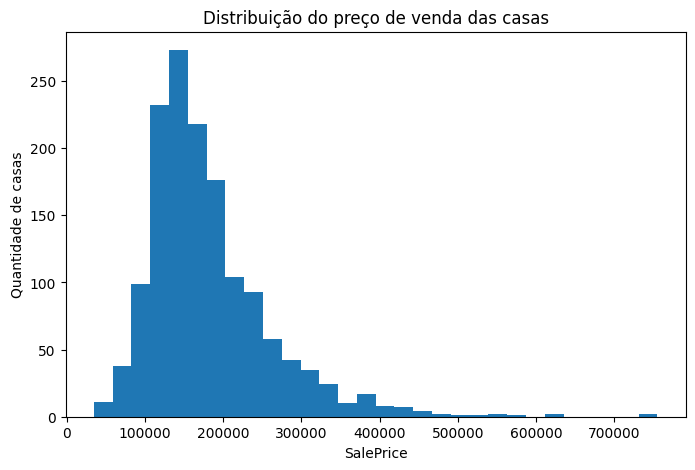

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=30)
plt.title('Distribuição do preço de venda das casas')
plt.xlabel('SalePrice')
plt.ylabel('Quantidade de casas')
plt.show()

df['SalePrice'].describe()

## 7. Correlação com o preço de venda

Nesta parte, usei correlação para ter uma ideia inicial de quais variáveis numéricas têm mais relação com o preço da casa.

In [8]:
correlacoes = df[colunas_numericas].corr()['SalePrice'].sort_values(ascending=False)
correlacoes.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

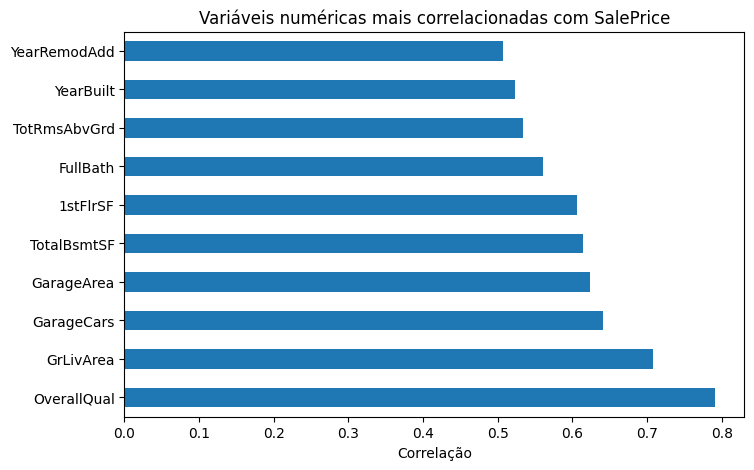

In [9]:
correlacoes.head(11).drop('SalePrice').plot(kind='barh', figsize=(8,5))
plt.title('Variáveis numéricas mais correlacionadas com SalePrice')
plt.xlabel('Correlação')
plt.show()

### Interpretação da correlação

Pelas correlações, variáveis como qualidade geral da casa (`OverallQual`), área útil acima do solo (`GrLivArea`), tamanho da garagem (`GarageCars` e `GarageArea`) e área total do porão (`TotalBsmtSF`) aparecem entre as mais relacionadas com o preço. Isso faz sentido, porque casas maiores e com melhor qualidade tendem a ter preço maior.

## 8. Visualizações simples

Para visualizar melhor a relação entre algumas variáveis e o preço, fiz gráficos de dispersão usando as variáveis que parecem mais importantes.

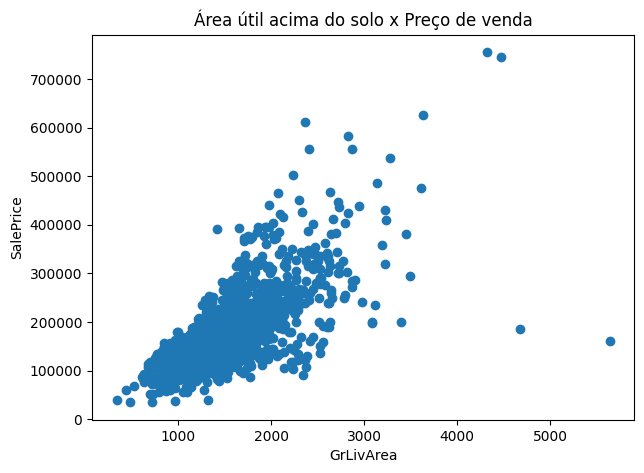

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('Área útil acima do solo x Preço de venda')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

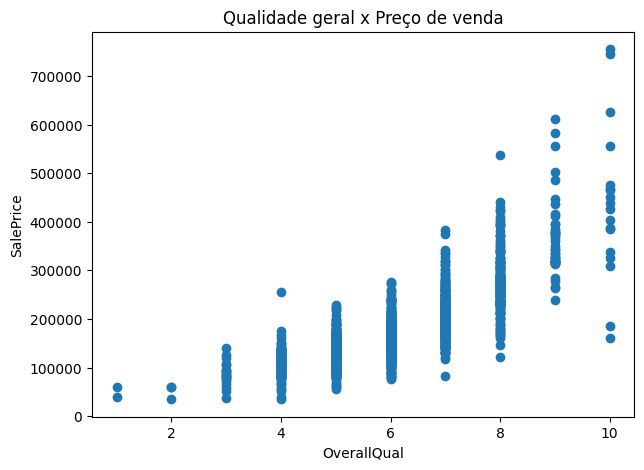

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(df['OverallQual'], df['SalePrice'])
plt.title('Qualidade geral x Preço de venda')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

## 9. Feature Engineering

Nesta etapa, fiz algumas transformações simples nos dados. A ideia foi criar variáveis que podem ajudar os modelos a entender melhor as casas.

Criei as seguintes variáveis:

- `Idade_Casa`: diferença entre o ano de venda e o ano de construção;
- `Idade_Reforma`: diferença entre o ano de venda e o ano da reforma;
- `Total_Banheiros`: soma aproximada dos banheiros completos e meios banheiros;
- `Area_Total`: soma de áreas importantes da casa;
- `Preco_Alto`: variável binária para classificação, onde 1 significa preço acima da mediana e 0 significa preço abaixo ou igual à mediana.

In [12]:
df['Idade_Casa'] = df['YrSold'] - df['YearBuilt']
df['Idade_Reforma'] = df['YrSold'] - df['YearRemodAdd']
df['Total_Banheiros'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
df['Area_Total'] = df['GrLivArea'] + df['TotalBsmtSF'] + df['GarageArea']

mediana_preco = df['SalePrice'].median()
df['Preco_Alto'] = (df['SalePrice'] > mediana_preco).astype(int)

print('Mediana do preço:', mediana_preco)
df[['SalePrice', 'Idade_Casa', 'Idade_Reforma', 'Total_Banheiros', 'Area_Total', 'Preco_Alto']].head()

Mediana do preço: 163000.0


,SalePrice,Idade_Casa,Idade_Reforma,Total_Banheiros,Area_Total,Preco_Alto
0,208500,5,5,3.5,3114,1
1,181500,31,31,2.5,2984,1
2,223500,7,6,3.5,3314,1
3,140000,91,36,2.0,3115,0
4,250000,8,8,3.5,4179,1
